In [ ]:
# @title
from IPython.display import HTML, display

cover_html = """
<div style="
    background-color: white;
    color: #222;
    padding: 40px 40px 30px 40px;
    border-radius: 15px;
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 4px 20px rgba(0,0,0,0.1);
    margin: 20px 0;
    text-align: center;
    position: relative;
">

    <!-- Top Banner Image -->
    <img src="https://www.redage.org/sites/default/files/img-logo-institucion/logo-itesm.png"
         style="width: 100%; max-width: 800px; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1);"
         alt="Banner">

    <!-- Title -->
    <h1 style="font-size: 2.5em; margin-bottom: 10px; color: #111;">Actividad 4 Implementación de un Algoritmo Bioinspirado de Búsqueda de Abejas</h1>

    <img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwokii.com%2Fwp-content%2Fuploads%2F2020%2F05%2Fabejas.jpg&f=1&nofb=1&ipt=beec8a8a5b06ca1d948d8eb7c01b1749be3281309c16c675be3ca974c0c01cdc"
     style="width: 100%; max-width: 450px; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1);"
     alt="Banner">


    <!-- Subject -->
    <p style="font-size: 1.2em; margin: 10px 0; color: #333;">
        <b>Diseño de algoritmos matemáticos bioinspirados (Gpo 202)</b>
    </p>

    <!-- Horizontal line -->
    <hr style="width: 50%; margin: 30px auto; border: 1px solid #ccc;">

        <!-- Team Members -->
    <div style="font-size: 1.1em; line-height: 1.6; color: #444;">
        <strong>Team Members:</strong><br>
        • Pablo Fernando Barrera Camacho - A01752281<br>
        • Carlos Manuel Ramos Gastélum - A01253791<br>
        • Carlos Manuel Delgado Vázquez - A01747037<br>
        • Diego Alejandro Parra Ruíz - A0180102<br>
    </div>

    <!-- Date -->
    <p style="margin-top: 25px; font-size: 1em; color: #555;">
        <strong>Fecha:</strong> 18 de Octubre del 2025
    </p>

</div>
"""

display(HTML(cover_html))



# 🐝 Algoritmo de las Abejas (Bees Algorithm)

**Objetivo:** Este notebook explica, paso a paso, una implementación simple del *Bees Algorithm* para optimización continua (minimización). Está pensado para **mostrarte** cada parte del código y **ejecutarlo** en Google Colab.

**Qué verás en este notebook:**
- Idea general del algoritmo (reclutamiento de abejas a sitios prometedores + exploración global con exploradoras).
- Estructura del código por funciones.
- Parámetros y su efecto (número de abejas, sitios, sitios élite, tamaño de parche y decremento, etc.).
- Visualización sencilla de las posiciones exploradas.

> El problema de prueba es minimizar $f(\mathbf{x}) = \sum_i x_i^2$ en un cuadrado $[-5,5]^2$.



## Resumen conceptual del algoritmo

1. **Población inicial**: generar `num_bees` posiciones aleatorias en el espacio de búsqueda.
2. **Evaluación**: calcular la *aptitud* (fitness) de cada abeja (el valor de la función objetivo).
3. **Selección de sitios**: ordenar por fitness y elegir `num_sites` mejores sitios (los primeros son **élite**).
4. **Búsqueda local (vecindad)**: alrededor de cada sitio, crear `e_bees` (si es élite) o `o_bees` vecinas y **quedarse con la mejor**.
5. **Exploradoras (scouts)**: completar la nueva generación con abejas aleatorias (búsqueda global).
6. **Ajuste de parche**: reducir `patch_size` con el factor `patch_dec` para ir refinando la búsqueda.
7. **Iterar**: repetir por `max_gens` generaciones y **guardar el mejor** encontrado.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Si usas este notebook localmente y aparece una ventana vacía,
# puedes agregar '%matplotlib inline' en una celda para ver los gráficos dentro del notebook.


## Función objetivo

In [ ]:
# Se define la función de rastrigin para su uso dentro del código

def rastrigin(vector: np.ndarray, A: float = 10) -> float:
    d = len(vector)  # dimensión
    return A * d + np.sum(vector**2 - A * np.cos(2 * np.pi * vector))


def objective_function(vector: np.ndarray) -> float:
    # vector**2 eleva cada componente al cuadrado; sum(...) suma todos esos cuadrados.

    return rastrigin(vector)


## Utilidades: vectores aleatorios y creación de abejas

In [ ]:

def random_vector(minmax: np.ndarray) -> np.ndarray:
    """Genera un vector aleatorio dentro de los límites `minmax`.

    Parámetros
    ---------
    minmax : np.ndarray de forma (d, 2)
        Para cada dimensión i, minmax[i, 0] = mínimo, minmax[i, 1] = máximo.
    """
    # np.random.random(len(minmax)) genera valores uniformes en [0,1) para cada dimensión.
    # Escalamos y trasladamos para caer dentro de [min_i, max_i] en cada coordenada.
    return minmax[:, 0] + (minmax[:, 1] - minmax[:, 0]) * np.random.random(len(minmax))


def create_random_bee(search_space: np.ndarray) -> dict:
    """Crea una abeja con posición aleatoria en el espacio de búsqueda."""
    return {"vector": random_vector(search_space)}


## Búsqueda local: generar vecinas y elegir la mejor

In [ ]:

def create_neigh_bee(site: np.ndarray, patch_size: float, search_space: np.ndarray) -> dict:
    """Crea una abeja en la vecindad de `site`.

    La vecindad se modela sumando o restando un valor aleatorio (en [0, patch_size])
    a cada coordenada. Luego, se recorta a los límites del espacio de búsqueda.
    """
    vector = []
    for i, v in enumerate(site):
        # Con 50% de probabilidad, movemos hacia + o hacia - en el eje i.
        if np.random.random() < 0.5:
            v = v + np.random.random() * patch_size
        else:
            v = v - np.random.random() * patch_size
        # Recorte a los límites [min_i, max_i].
        v = max(v, search_space[i, 0])
        v = min(v, search_space[i, 1])
        vector.append(v)
    return {"vector": np.array(vector, float)}


def search_neigh(parent: dict, neigh_size: int, patch_size: float, search_space: np.ndarray) -> dict:
    """Explora la vecindad de `parent` creando `neigh_size` vecinas y retorna la mejor."""
    neighborhood = []
    for _ in range(neigh_size):
        bee = create_neigh_bee(parent["vector"], patch_size, search_space)
        bee["fitness"] = objective_function(bee["vector"])  # evaluar cada vecina
        neighborhood.append(bee)
    # Ordenar por fitness ascendente (minimizamos).
    neighborhood.sort(key=lambda b: b["fitness"])
    return neighborhood[0]  # la mejor vecina


## Exploración global: abejas exploradoras (scouts)

In [ ]:

def create_scout_bees(search_space: np.ndarray, num_scouts: int) -> list:
    """Crea `num_scouts` abejas aleatorias para explorar nuevas regiones."""
    return [create_random_bee(search_space) for _ in range(num_scouts)]


## Algoritmo principal

In [ ]:

def bees_algorithm(max_gens: int,
                   search_space: np.ndarray,
                   num_bees: int,
                   num_sites: int,
                   elite_sites: int,
                   patch_size: float,
                   patch_dec: float,
                   e_bees: int,
                   o_bees: int,
                   track_points: bool = True) -> dict:
    """Implementación del Bees Algorithm.

    Parámetros clave para explicar en clase:
    - `num_bees`: tamaño de la población total en cada generación.
    - `num_sites`: cuántos mejores sitios serán explotados (búsqueda local).
    - `elite_sites`: cuántos de esos `num_sites` reciben más abejas vecinas (intensificación).
    - `patch_size`: radio de vecindad inicial.
    - `patch_dec`: factor multiplicativo para reducir `patch_size` en cada iteración.
    - `e_bees`: número de vecinas por sitio élite.
    - `o_bees`: número de vecinas por sitio no élite.

    Retorna
    -------
    dict con la mejor solución encontrada: {'vector': np.ndarray, 'fitness': float}
    """
    best = None
    # 1) Población inicial
    pop = [create_random_bee(search_space) for _ in range(num_bees)]

    # Para graficar las posiciones visitadas (opcional)
    xp, yp = ([] , [])

    for gen in range(max_gens):
        # 2) Evaluación de toda la población
        for i in range(num_bees):
            pop[i]['fitness'] = objective_function(pop[i]['vector'])
            if track_points and search_space.shape[0] >= 2:
                # Guardar las dos primeras coordenadas para graficar en 2D
                xp.append(pop[i]['vector'][0])
                yp.append(pop[i]['vector'][1])

        # 3) Ordenar por fitness (mejores primero)
        pop.sort(key=lambda b: b['fitness'])

        # 4) Actualizar mejor global
        if (best is None) or (pop[0]['fitness'] < best['fitness']):
            best = {'vector': pop[0]['vector'].copy(), 'fitness': float(pop[0]['fitness'])}

        # 5) Explotaciónn: búsqueda local en los mejores sitios
        next_gen = []
        top_sites = pop[:num_sites]
        for i, parent in enumerate(top_sites):
            neigh_size = e_bees if i < elite_sites else o_bees
            best_neigh = search_neigh(parent, neigh_size, patch_size, search_space)
            next_gen.append(best_neigh)

        # 6) Exploración: completar con abejas exploradoras
        scouts = create_scout_bees(search_space, num_bees - num_sites)
        pop = next_gen + scouts

        # 7) Reducir tamaño de parche (refinamiento)
        patch_size *= patch_dec

        # Mensaje de seguimiento (útil para los alumnos)
        print(f" > it={gen+1}, patch_size={patch_size:.4f}, best_f={best['fitness']:.6f}")

    # Visualización 2D simple (si el problema tiene al menos 2 variables)
    if track_points and search_space.shape[0] >= 2:
        plt.figure()
        plt.axis([search_space[0, 0], search_space[0, 1],
                  search_space[1, 0], search_space[1, 1]])
        plt.plot(xp, yp, 'o', markersize=2)  # puntos explorados
        plt.plot([best['vector'][0]], [best['vector'][1]], 's', markersize=8)  # mejor punto
        plt.title('Trayectoria de exploración (2 primeras dimensiones)')
        plt.xlabel('x1'); plt.ylabel('x2')
        plt.show()

    return best


## Parámetros del experimento y ejecución

In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

# === PASO 1: Lista dinámica de entradas numéricas ===
Inputs = widgets.VBox()


# Botones
accept_button = widgets.Button(description="Aceptar", button_style='info')

input1 = widgets.FloatText(description="Generaciones de Abejas", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input2 = widgets.FloatText(description="# de Abejas", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input3 = widgets.FloatText(description="# de Sitios a Explorar", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input4 = widgets.FloatText(description="# Sitios Élite", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input5 = widgets.FloatText(description="Tamaño de Vecindad de Exploración", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input6 = widgets.FloatText(description="Proporción de Reducción de Vecindad", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input7 = widgets.FloatText(description="Vecinas en sitios Élite", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
input8 = widgets.FloatText(description="Vecinas en Sitio no Élite", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))

Inputs.children = [input1, input2, input3, input4, input5, input6, input7, input8, accept_button]


# Área de salida para mensajes
output = widgets.Output()

# Variables para almacenar los valores guardados
alpha = beta = rho = None
values = []

def save_inputs(_):
    with output:
        clear_output()
        inputs = Inputs.children
        nums = []
        values = []  # Reset values list for each click
        for widget in inputs[:-1]:  # Saltar el botón
            if widget.value is None:
                print("Error: Uno o más campos están vacíos.")
                return
            values.append(widget.value)

        # Guardar en variables separadas
        global max_gens, num_bees, num_sites, elite_sites, patch_size, patch_dec, e_bees, o_bees
        max_gens, num_bees, num_sites, elite_sites, patch_size, patch_dec, e_bees, o_bees = values
        print("Se guardaron los parámetros:")
        print(f"Generaciones = {max_gens}, # Abejas = {num_bees}, # Sitios = {num_sites}, # elite = {elite_sites}, Patch Tamaño = {patch_size}, Patch Dec = {patch_dec}, Vecinas Élite = {e_bees}, Vecinas No Élite = {o_bees}")

        accept_button.disabled = True
        for widget in inputs:
            widget.disabled = True

# Asignar función al botón de guardar
accept_button.on_click(save_inputs)

# === Mostrar todo en pantalla ===
display(widgets.HTML("<h3>Ingresar datos y parámetros</h3>"))
display(output)
display(Inputs)

HTML(value='<h3>Ingresar datos y parámetros</h3>')

Output()

 > it=1, patch_size=0.2500, best_f=5.687150
 > it=2, patch_size=0.1250, best_f=5.687150
 > it=3, patch_size=0.0625, best_f=1.566905
 > it=4, patch_size=0.0312, best_f=1.378920
 > it=5, patch_size=0.0156, best_f=1.054049
 > it=6, patch_size=0.0078, best_f=1.054049
 > it=7, patch_size=0.0039, best_f=1.054049
 > it=8, patch_size=0.0020, best_f=1.036673
 > it=9, patch_size=0.0010, best_f=1.021092
 > it=10, patch_size=0.0005, best_f=1.020734
 > it=11, patch_size=0.0002, best_f=1.015670
 > it=12, patch_size=0.0001, best_f=1.013775
 > it=13, patch_size=0.0001, best_f=1.013141
 > it=14, patch_size=0.0000, best_f=1.012853
 > it=15, patch_size=0.0000, best_f=1.012693
 > it=16, patch_size=0.0000, best_f=1.012628
 > it=17, patch_size=0.0000, best_f=1.012591
 > it=18, patch_size=0.0000, best_f=1.012570
 > it=19, patch_size=0.0000, best_f=1.012560
 > it=20, patch_size=0.0000, best_f=1.012552
 > it=21, patch_size=0.0000, best_f=1.012550
 > it=22, patch_size=0.0000, best_f=1.012549
 > it=23, patch_siz

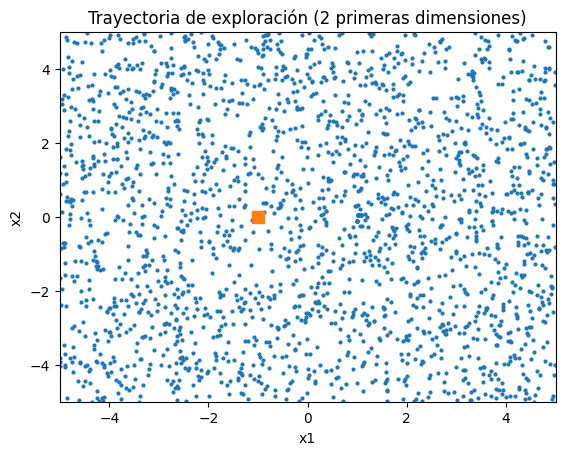


Hecho.
Mejor solución: f=1.012547, x=[-1.00009747 -0.00789086]


In [ ]:

# === Configuración del problema ===
problem_size = 2  # número de variables (si lo subes a 3+, el gráfico usaría solo x1 y x2)
search_space = np.array([[-5.0, +5.0] for _ in range(problem_size)], float)  # dominios por dimensión

# === Configuración del algoritmo ===
max_gens   = int(max_gens)    # generaciones (puedes subirlo para más precisión)
num_bees   = int(num_bees)   # tamaño de población
num_sites  = int(num_sites)    # sitios a explotar
elite_sites = int(elite_sites)    # cuantos sitios son élite
patch_size = float(patch_size)   # tamaño de vecindad inicial
patch_dec  = float(patch_dec)  # multiplicador <1 para reducir patch_size
e_bees     = int(e_bees)     # vecinas por sitio élite
o_bees     = int(o_bees)   # vecinas por sitio no élite

best = bees_algorithm(max_gens, search_space, num_bees, num_sites,
                      elite_sites, patch_size, patch_dec, e_bees, o_bees,
                      track_points=True)

print(f"\nHecho.\nMejor solución: f={best['fitness']:.6f}, x={best['vector']}")


# Comparación Sphere vs Rastrigin

Sphere → fitness final ≈ 0.000125
Rastrigin → fitness final ≈ 1.111735


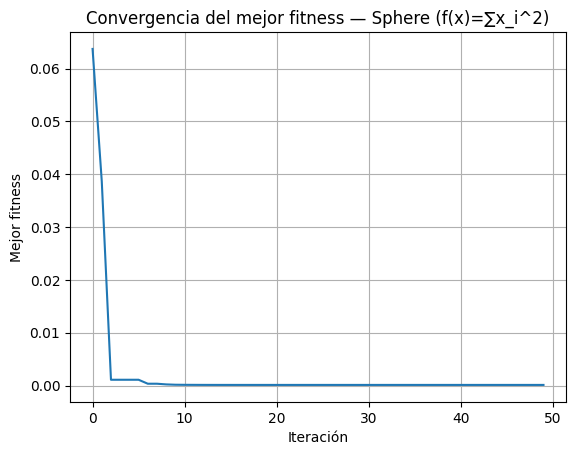

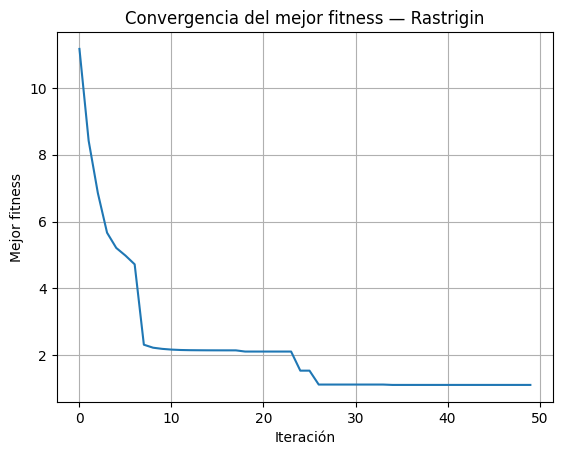

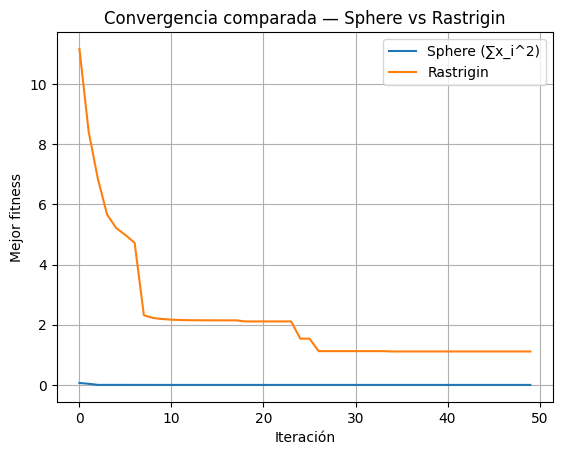

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Definir Sphere (función original f(x)=sum x_i^2)
def sphere(vector: np.ndarray) -> float:
    return float(np.sum(vector**2))

# 2) Envoltura del algoritmo para registrar la HISTORIA del mejor fitness
def run_with_history(obj_fn,
                     max_gens, search_space, num_bees, num_sites, elite_sites,
                     patch_size, patch_dec, e_bees, o_bees):
    """
    Replica el bucle principal de tu bees_algorithm pero guardando el mejor fitness por iteración.
    Usa tus mismas utilidades: create_random_bee, search_neigh, create_scout_bees.
    """
    # Cambiamos temporalmente la función objetivo global
    global objective_function
    _old_obj = objective_function
    objective_function = obj_fn

    best = None
    hist = []

    # pob. inicial
    pop = [create_random_bee(search_space) for _ in range(num_bees)]
    psize = float(patch_size)

    for gen in range(max_gens):
        # 2) Evaluación
        for i in range(num_bees):
            pop[i]['fitness'] = objective_function(pop[i]['vector'])

        # 3) Ordenar y 4) Mejor global
        pop.sort(key=lambda b: b['fitness'])
        if (best is None) or (pop[0]['fitness'] < best['fitness']):
            best = {'vector': pop[0]['vector'].copy(), 'fitness': float(pop[0]['fitness'])}
        hist.append(best['fitness'])

        # 5) Explotación en sitios top
        next_gen = []
        top_sites = pop[:num_sites]
        for i, parent in enumerate(top_sites):
            neigh_size = e_bees if i < elite_sites else o_bees
            best_neigh = search_neigh(parent, neigh_size, psize, search_space)
            next_gen.append(best_neigh)

        # 6) Exploración (scouts) y nueva población
        scouts = create_scout_bees(search_space, num_bees - num_sites)
        pop = next_gen + scouts

        # 7) Reducción de parche (refinamiento)
        psize *= patch_dec

    # restaurar función objetivo original
    objective_function = _old_obj
    return np.array(hist)

problem_size = 2
search_space = np.array([[-5.0, 5.0] for _ in range(problem_size)], float)


hist_sphere    = run_with_history(sphere,    max_gens, search_space, num_bees, num_sites, elite_sites,
                                  patch_size, patch_dec, e_bees, o_bees)
hist_rastrigin = run_with_history(rastrigin, max_gens, search_space, num_bees, num_sites, elite_sites,
                                  patch_size, patch_dec, e_bees, o_bees)

print(f"Sphere → fitness final ≈ {hist_sphere[-1]:.6f}")
print(f"Rastrigin → fitness final ≈ {hist_rastrigin[-1]:.6f}")

plt.figure()
plt.plot(hist_sphere)
plt.xlabel("Iteración")
plt.ylabel("Mejor fitness")
plt.title("Convergencia del mejor fitness — Sphere (f(x)=∑x_i^2)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_rastrigin)
plt.xlabel("Iteración")
plt.ylabel("Mejor fitness")
plt.title("Convergencia del mejor fitness — Rastrigin")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_sphere, label="Sphere (∑x_i^2)")
plt.plot(hist_rastrigin, label="Rastrigin")
plt.xlabel("Iteración")
plt.ylabel("Mejor fitness")
plt.title("Convergencia comparada — Sphere vs Rastrigin")
plt.legend()
plt.grid(True)
plt.show()
